# Problem Statement
Supply chain operations involve various factors such as order quantity, transportation distance, supplier lead time, inventory levels, demand, and supplier reliability. These factors can affect delivery time and lead to delays or inefficient shipment management. Traditional analysis may not effectively identify delivery risks, shipment patterns, and unusual shipments from large amounts of supply chain data. Therefore, a data-driven system is needed to predict delivery outcomes, identify shipment profiles, and detect potential anomalies.

# Objective
The objective of this project is to build an end-to-end Supply Chain Intelligence system that leverages machine learning to predict, classify, and profile shipment behavior, enabling data-driven decision-making in logistics operations.

Specifically, the project aims to:

Clean and prepare raw supply chain data — handling missing values, outliers, and skewed distributions — to ensure a reliable foundation for modeling.
Explore and engineer features that capture meaningful operational relationships (e.g., cost efficiency, inventory-demand balance, supplier reliability) beyond what raw columns alone express.
Predict delivery time (Delivery_Time_days) using regression models, enabling proactive planning around expected shipment duration.
Classify delivery outcomes (Delivery_Status) using classification models, allowing early identification of shipments at risk of delay.
Segment shipments into operational profiles using unsupervised clustering (KMeans), revealing natural groupings based on volume, distance, and supplier risk.
Detect anomalous shipments using DBSCAN, flagging unusual feature combinations that may warrant manual review — independent of labeled outcomes.
Compare multiple algorithms across both supervised tasks to identify the best-performing model for each, based on standard evaluation metrics (MAE, RMSE, R² for regression; Accuracy, Precision, Recall, F1 for classification).
Deliver a practical, deployable solution that combines all of the above into a single system capable of forecasting, classifying, and flagging supply chain risk from a single shipment record.

# Import Libraries

In [1]:
import numpy as np;
import pandas as pd;
import matplotlib.pyplot as plt;
import seaborn as sns;

# Load Dataset

In [2]:
df=pd.read_csv("/kaggle/input/datasets/tahsina007/supplychaindataset/supply_chain_intelligence_Dataset.csv")
display(df);
print(df.shape);
display(df.head(7));
display(df.tail(4));

,Product_Category,Supplier_Region,Shipping_Mode,Warehouse_Type,Order_Quantity,Distance_km,Supplier_Lead_Time_days,Transportation_Cost,Inventory_Level,Demand_Forecast,Supplier_Reliability_Score,Historical_Delay_Rate,Delivery_Time_days,Delivery_Status
0,Automotive Parts,Europe,Sea,Hybrid,414.0,7212.6,16.0,3461.43,879.0,589.0,87.5,0.114,43.4,Delayed
1,Perishable Food,Europe,Air,Cross-Dock,1786.0,3226.7,7.0,51125.28,2594.0,2511.0,93.2,0.097,8.9,Early
2,Automotive Parts,East Asia,Rail,Automated,320.0,10997.2,19.0,7934.74,399.0,366.0,87.9,0.053,58.1,Severely Delayed
3,Furniture,East Asia,Sea,Automated,90.0,9143.3,23.0,1168.56,116.0,99.0,91.4,0.055,63.1,Delayed
4,Electronics,South Asia,Sea,Hybrid,130.0,5720.1,24.0,1059.25,175.0,136.0,62.4,0.313,50.8,Delayed
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,Perishable Food,Southeast Asia,Air,Hybrid,257.0,7368.7,9.0,16370.74,144.0,336.0,73.4,0.153,17.5,On Time
9996,Apparel,North America,Rail,Manual,628.0,3675.6,8.0,5068.13,608.0,729.0,87.6,0.056,16.8,On Time
9997,Electronics,Southeast Asia,Road,Hybrid,165.0,7301.8,10.0,3924.57,115.0,122.0,74.5,0.197,37.6,Delayed
9998,Apparel,Europe,Road,Cross-Dock,819.0,5608.5,8.0,16152.14,850.0,1045.0,87.2,0.076,27.1,On Time


(10000, 14)


,Product_Category,Supplier_Region,Shipping_Mode,Warehouse_Type,Order_Quantity,Distance_km,Supplier_Lead_Time_days,Transportation_Cost,Inventory_Level,Demand_Forecast,Supplier_Reliability_Score,Historical_Delay_Rate,Delivery_Time_days,Delivery_Status
0,Automotive Parts,Europe,Sea,Hybrid,414.0,7212.6,16.0,3461.43,879.0,589.0,87.5,0.114,43.4,Delayed
1,Perishable Food,Europe,Air,Cross-Dock,1786.0,3226.7,7.0,51125.28,2594.0,2511.0,93.2,0.097,8.9,Early
2,Automotive Parts,East Asia,Rail,Automated,320.0,10997.2,19.0,7934.74,399.0,366.0,87.9,0.053,58.1,Severely Delayed
3,Furniture,East Asia,Sea,Automated,90.0,9143.3,23.0,1168.56,116.0,99.0,91.4,0.055,63.1,Delayed
4,Electronics,South Asia,Sea,Hybrid,130.0,5720.1,24.0,1059.25,175.0,136.0,62.4,0.313,50.8,Delayed
5,Industrial Equipment,East Asia,Sea,Manual,89.0,8871.0,25.0,1178.85,71.0,86.0,84.0,0.098,71.3,Severely Delayed
6,Automotive Parts,South Asia,Sea,Hybrid,213.0,6239.6,22.0,1965.62,180.0,161.0,78.5,0.129,48.2,Delayed


,Product_Category,Supplier_Region,Shipping_Mode,Warehouse_Type,Order_Quantity,Distance_km,Supplier_Lead_Time_days,Transportation_Cost,Inventory_Level,Demand_Forecast,Supplier_Reliability_Score,Historical_Delay_Rate,Delivery_Time_days,Delivery_Status
9996,Apparel,North America,Rail,Manual,628.0,3675.6,8.0,5068.13,608.0,729.0,87.6,0.056,16.8,On Time
9997,Electronics,Southeast Asia,Road,Hybrid,165.0,7301.8,10.0,3924.57,115.0,122.0,74.5,0.197,37.6,Delayed
9998,Apparel,Europe,Road,Cross-Dock,819.0,5608.5,8.0,16152.14,850.0,1045.0,87.2,0.076,27.1,On Time
9999,Perishable Food,East Asia,Air,Automated,727.0,12420.7,NaN,89347.00,549.0,695.0,78.9,0.158,26.1,On Time


# Dataset Overview
Getting some info from the dataset like the column names , no of non zero values are there in each columna and statistical overview.

In [3]:
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Product_Category            9966 non-null   object 
 1   Supplier_Region             9973 non-null   object 
 2   Shipping_Mode               9959 non-null   object 
 3   Warehouse_Type              9953 non-null   object 
 4   Order_Quantity              9939 non-null   float64
 5   Distance_km                 9959 non-null   float64
 6   Supplier_Lead_Time_days     9932 non-null   float64
 7   Transportation_Cost         9905 non-null   float64
 8   Inventory_Level             9919 non-null   float64
 9   Demand_Forecast             9925 non-null   float64
 10  Supplier_Reliability_Score  9939 non-null   float64
 11  Historical_Delay_Rate       9953 non-null   float64
 12  Delivery_Time_days          10000 non-null  float64
 13  Delivery_Status             1000

# Missing Value Analysis
Checking each column for missing/null values to determine whether imputation is needed before modeling.

In [4]:
print(df.isnull().sum())
print(df.isnull().sum().sum());
m=df.isnull().sum().sum();
print("The % of data missing in the table is ",(m/10000)*100,"%")

Product_Category              34
Supplier_Region               27
Shipping_Mode                 41
Warehouse_Type                47
Order_Quantity                61
Distance_km                   41
Supplier_Lead_Time_days       68
Transportation_Cost           95
Inventory_Level               81
Demand_Forecast               75
Supplier_Reliability_Score    61
Historical_Delay_Rate         47
Delivery_Time_days             0
Delivery_Status                0
dtype: int64
678
The % of data missing in the table is  6.78 %


# Missing Value Treatment
Handling missing values (if any) — numeric columns are imputed using the median, and categorical columns using the most frequent value. Simple Imputer is used here to fill the missing values.

In [5]:
from sklearn.impute import SimpleImputer

num_col=df.select_dtypes(include='number').columns.drop(['Delivery_Time_days'])
cat_col=df.select_dtypes(include='object').columns.drop(['Delivery_Status'])

si_num=SimpleImputer(strategy='median')
df[num_col]=si_num.fit_transform(df[num_col])

si_cat=SimpleImputer(strategy='most_frequent')
df[cat_col]=si_cat.fit_transform(df[cat_col])

print("Missing values from each column is\n");
print(df.isnull().sum())

Missing values from each column is

Product_Category              0
Supplier_Region               0
Shipping_Mode                 0
Warehouse_Type                0
Order_Quantity                0
Distance_km                   0
Supplier_Lead_Time_days       0
Transportation_Cost           0
Inventory_Level               0
Demand_Forecast               0
Supplier_Reliability_Score    0
Historical_Delay_Rate         0
Delivery_Time_days            0
Delivery_Status               0
dtype: int64


# Duplicasy Check

In [6]:
print("Total duplicate rows =",df.duplicated().sum())

Total duplicate rows = 0


# Exploratory Data Analysis (EDA)
Visualizing feature distributions and relationships using multiple plot types to understand the underlying data patterns before modeling. Performing VIF(variance_inflation_factor) to get the idea about multicollinearity among all the numerical features. 

In [7]:

from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

X = add_constant(df[num_col])
vif = pd.Series([variance_inflation_factor(X.values, i)for i in range(X.shape[1])], index=X.columns).drop('const')
print("Variance Inflation Factor (VIF)\n\n",vif.sort_values(ascending=False))

Variance Inflation Factor (VIF)

 Demand_Forecast               19.416426
Order_Quantity                17.587561
Inventory_Level                4.899304
Supplier_Reliability_Score     2.674418
Transportation_Cost            2.474775
Historical_Delay_Rate          2.469759
Supplier_Lead_Time_days        1.757109
Distance_km                    1.725915
dtype: float64


# Heatmap
A correlation heatmap is used to visually identify relationships and potential multicollinearity between numerical features, while VIF provides a more detailed numerical measurement of multicollinearity for each individual input feature.

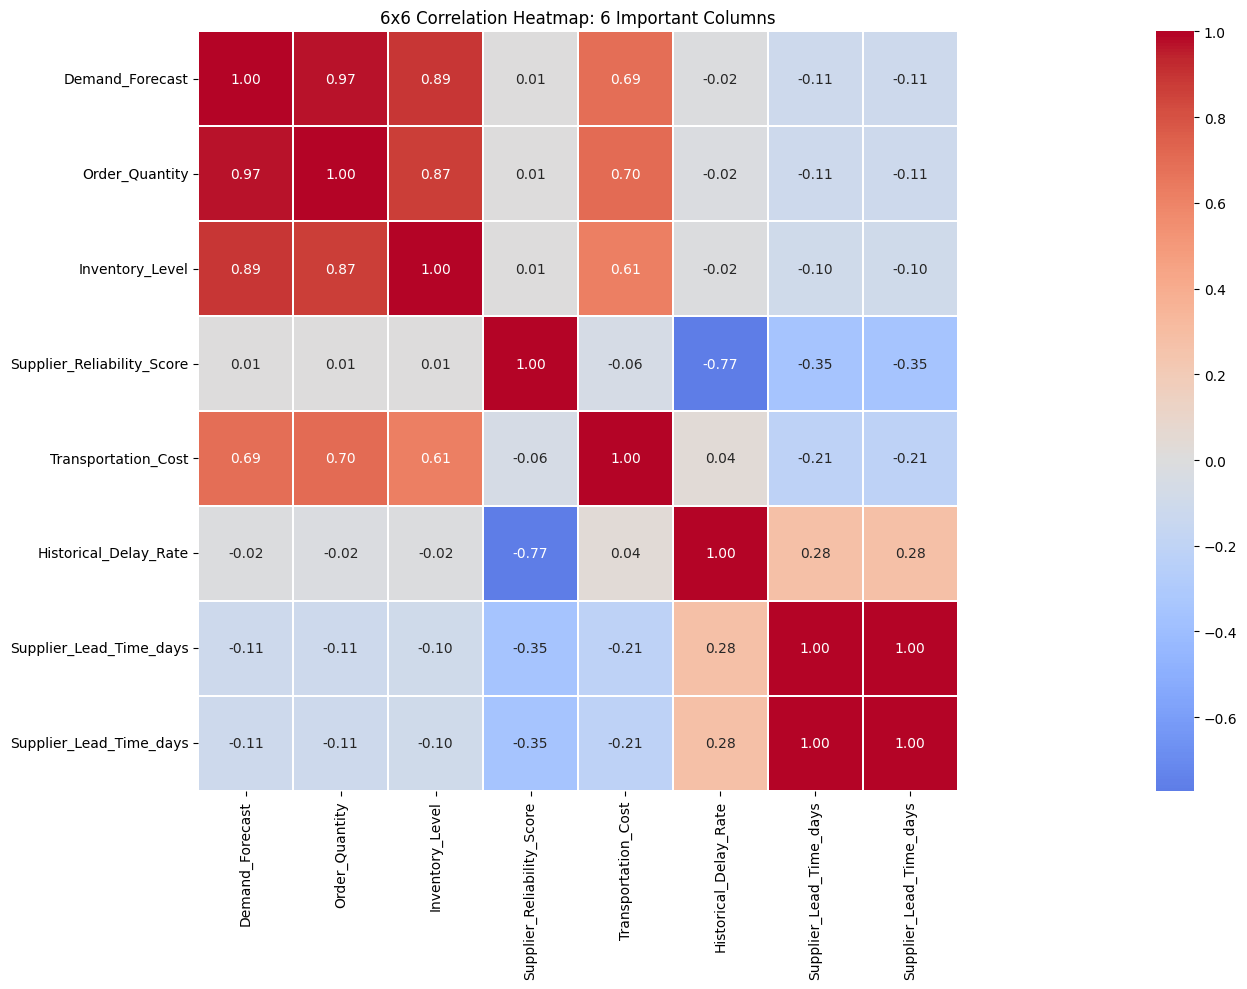

In [8]:
imp8 = ['Demand_Forecast', 'Order_Quantity', 'Inventory_Level',
        'Supplier_Reliability_Score', 'Transportation_Cost', 'Historical_Delay_Rate','Supplier_Lead_Time_days','Supplier_Lead_Time_days']

# Compute correlation matrix
corr_matrix = df[imp8].corr()

# Shorter labels for readability
labels = ['Demand_Forecast', 'Order_Quantity', 'Inventory_Level',
        'Supplier_Reliability_Score', 'Transportation_Cost', 'Historical_Delay_Rate','Supplier_Lead_Time_days','Supplier_Lead_Time_days']

# Plot heatmap
plt.figure(figsize=(40,10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            square=True, linewidths=0.3,
            xticklabels=labels, yticklabels=labels)
plt.title('6x6 Correlation Heatmap: 6 Important Columns')
plt.tight_layout()
plt.show()

# Regplot
It is mainly used to visualize the relationship between a numerical feature and the target variable and check whether a linear trend exists

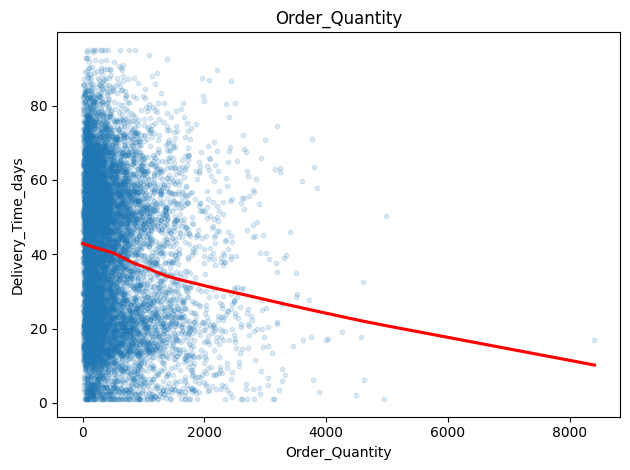

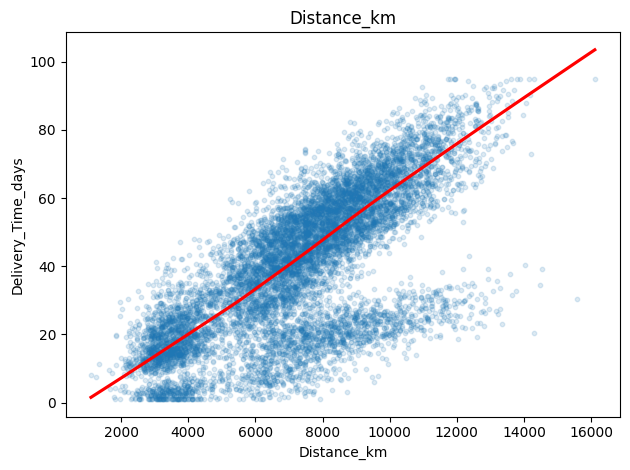

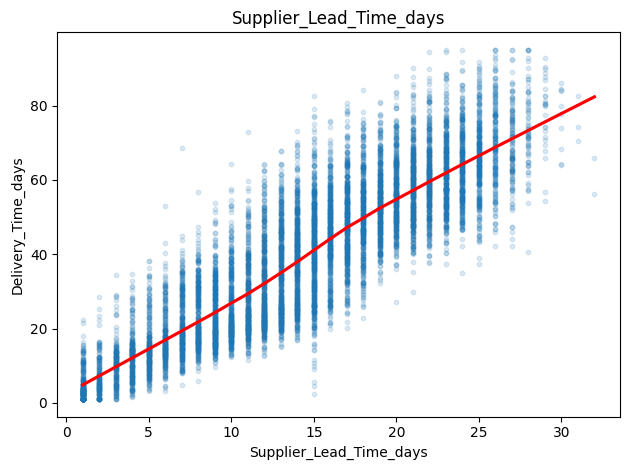

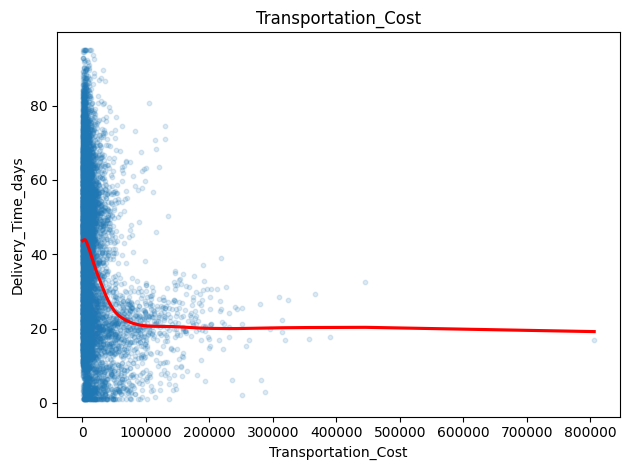

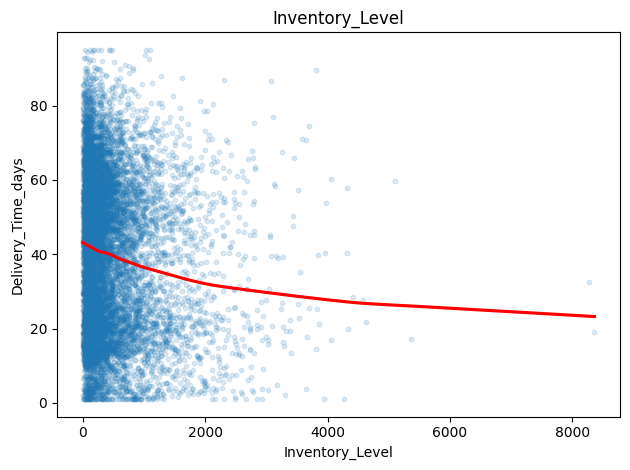

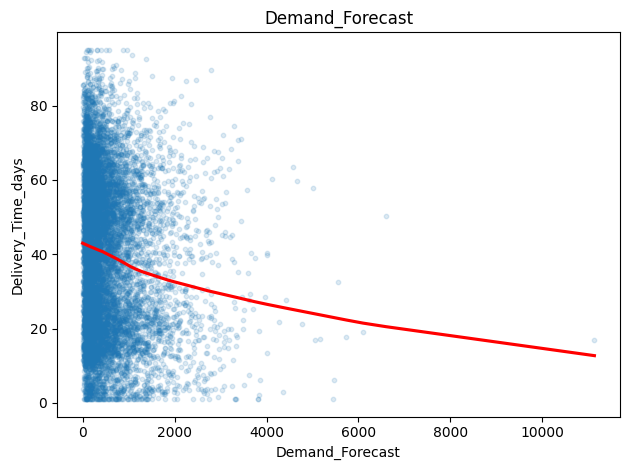

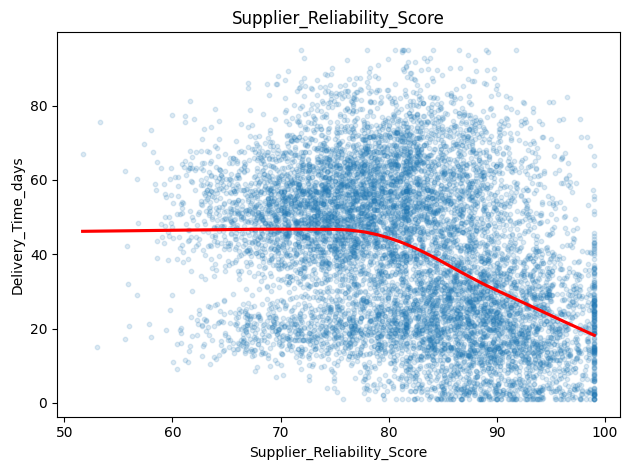

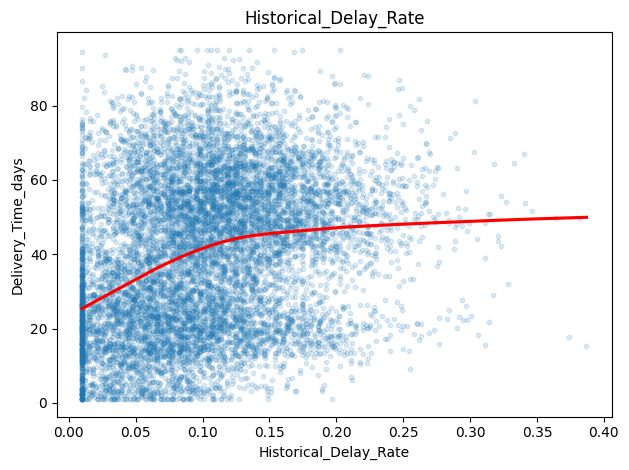

In [9]:
for col in num_col:
    sns.regplot(data=df, x=col, y='Delivery_Time_days',
                scatter_kws={'alpha': 0.15, 's': 10}, 
                line_kws={'color': 'red'}, lowess=True)
    plt.title(col)
    plt.tight_layout()
    plt.show() 

# Histplot
Done to check the data distribution of each column and also the skewness.

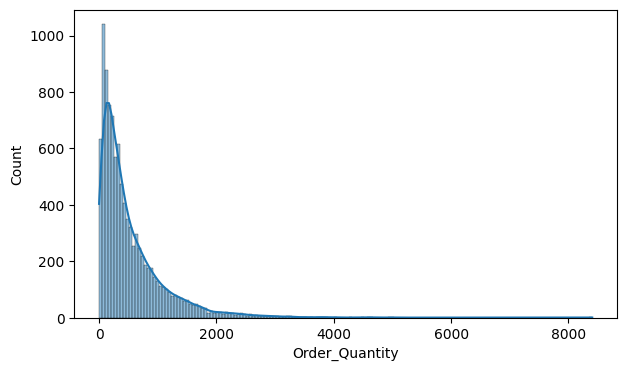

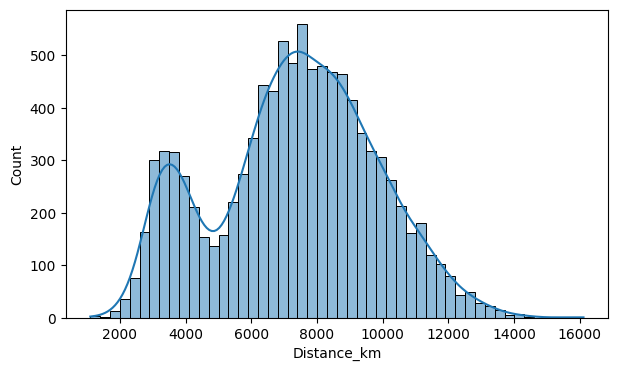

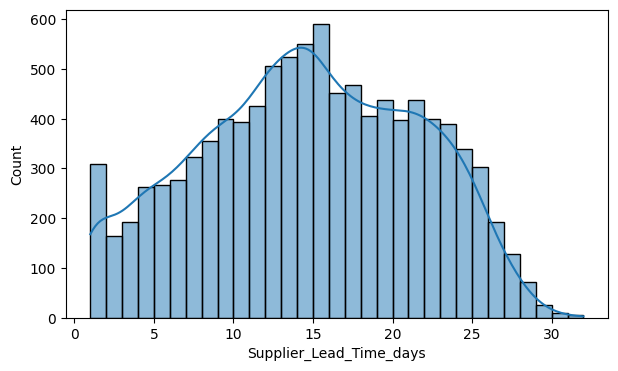

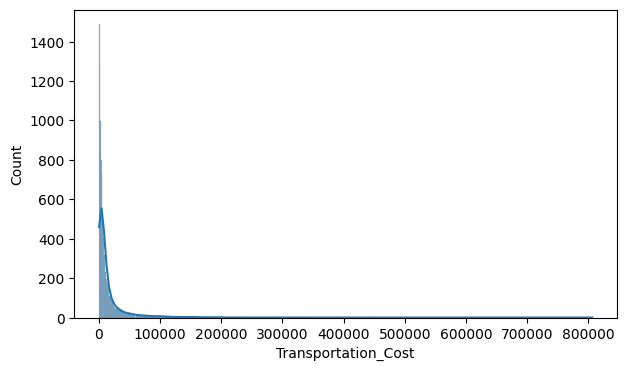

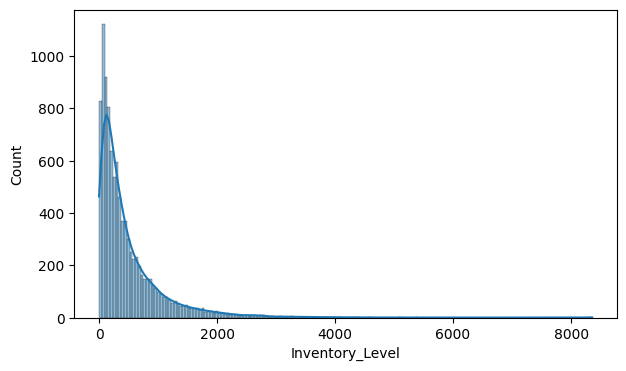

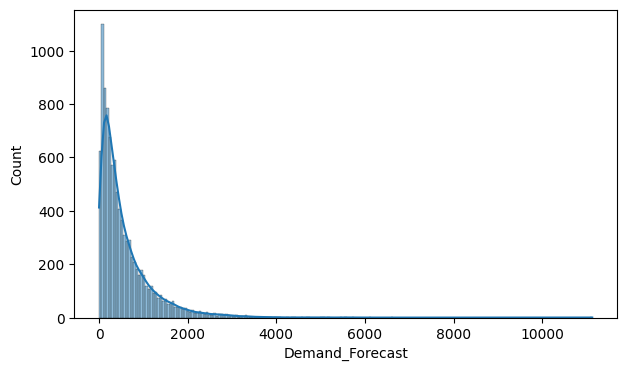

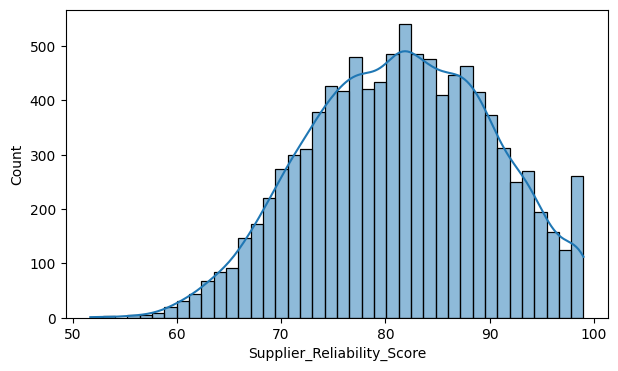

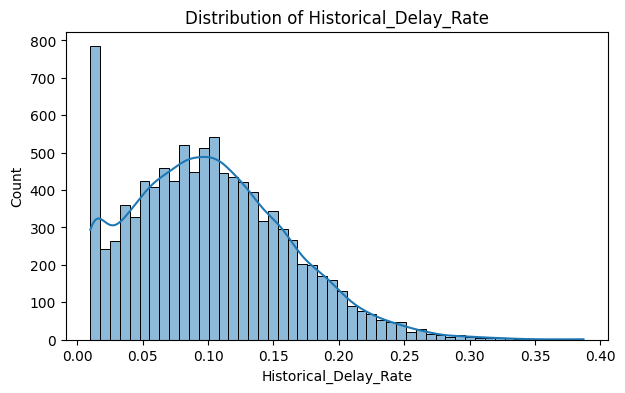

In [10]:
for col in num_col:
    plt.figure(figsize=(7, 4))
    sns.histplot(df[col],kde=True)

plt.title(f"Distribution of {col}")
plt.show()

# Boxplot
Used to check the outliers in each feature

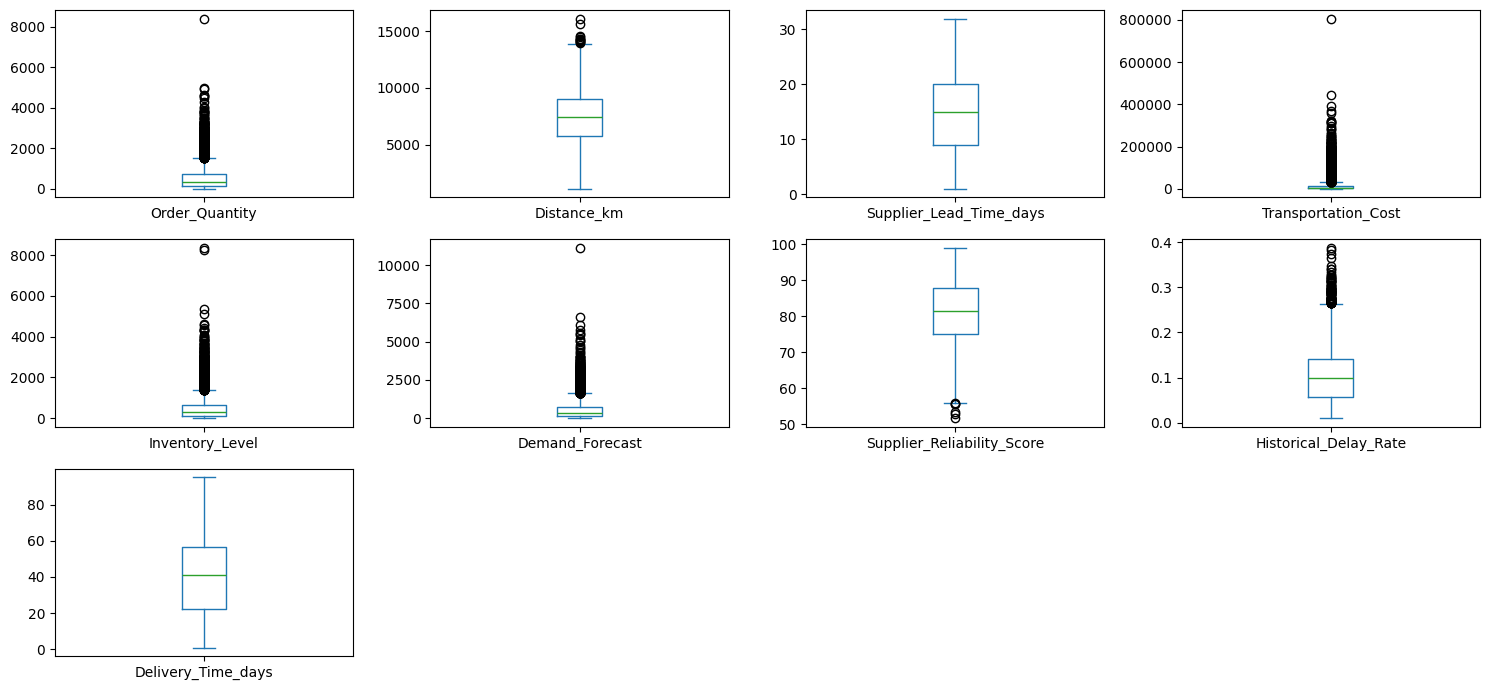

In [11]:
num_col = df.select_dtypes(include='number').columns
df[num_col].plot(kind='box', subplots=True, layout=(3,4), figsize=(15,7))
plt.tight_layout()
plt.show()

# No of outliers in each feature

In [12]:
outlier_counts = {}

for col in num_col:
    
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
    ]
    
    outlier_counts[col] = len(outliers)

print(outlier_counts)

{'Order_Quantity': 577, 'Distance_km': 12, 'Supplier_Lead_Time_days': 0, 'Transportation_Cost': 1218, 'Inventory_Level': 697, 'Demand_Forecast': 624, 'Supplier_Reliability_Score': 6, 'Historical_Delay_Rate': 89, 'Delivery_Time_days': 0}


# Piechart - to showcase categorical features distribution
A pie chart is used to visualize the percentage distribution of observations across different categories in a categorical feature

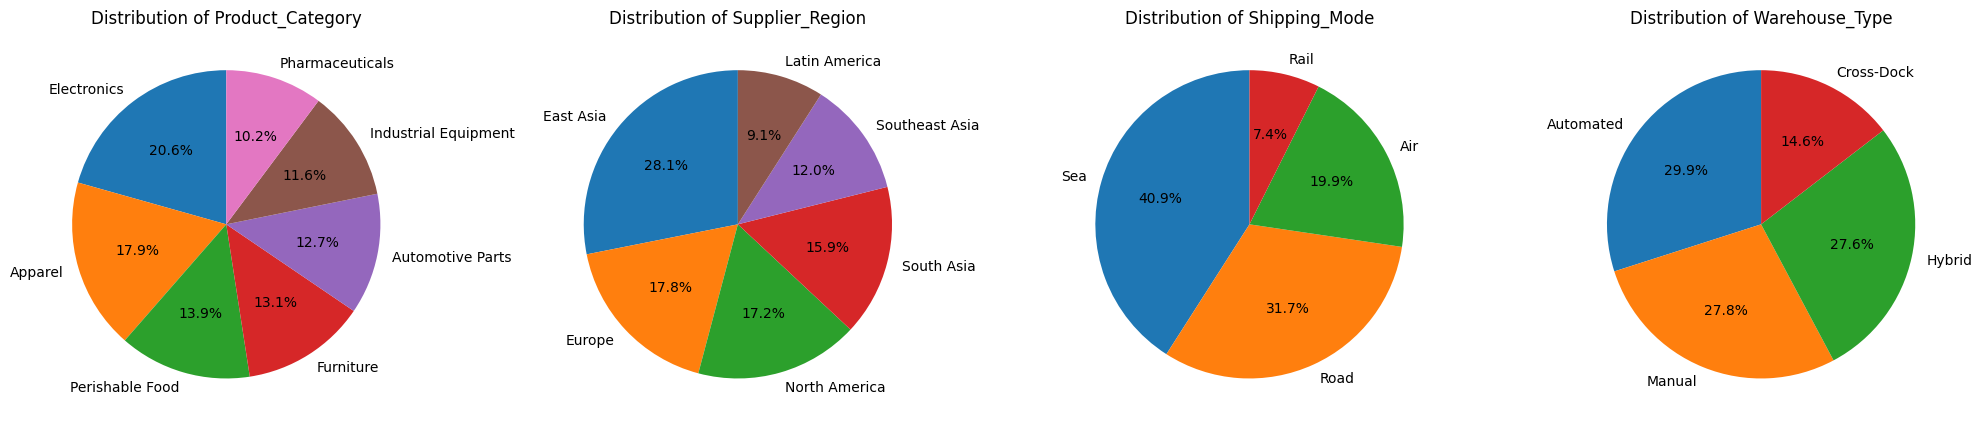

In [13]:
fig, axes = plt.subplots(2, 4, figsize=(20, 18))

# Convert 2D axes array into a 1D array
axes = axes.flatten()

for ax, col in zip(axes, cat_col):

    # Count original category names
    value_counts = df[col].value_counts()

    ax.pie(
        value_counts.values,
        labels=value_counts.index,
        autopct='%1.1f%%',
        startangle=90
    )

    ax.set_title(f'Distribution of {col}')

# Remove unused subplots if any
for ax in axes[len(cat_col):]:
    ax.remove() 

plt.tight_layout()
plt.show()

# Feature/Target Separation

In [14]:
X = df.drop(columns=['Delivery_Time_days','Delivery_Status'])
y1 = df['Delivery_Time_days']
y2 = df['Delivery_Status'] 

# Train-Test Split for regression

In [15]:
from sklearn.model_selection import train_test_split
Xr_train, Xr_test, yr_train, yr_test = train_test_split(X, y1, test_size=0.2, random_state=42)
Xr_train, Xr_test = Xr_train.copy(), Xr_test.copy()

# Functional - Log Transformer
The main purposes of it are:

1. Reduce right skewness
Makes a highly skewed distribution more balanced.

2. Compress large values
Prevents extremely large observations from dominating the model.

3. Reduce the influence of extreme values
It doesn't remove outliers, but it reduces their numerical magnitude.

4. Sometimes improve model performance
Especially for models that benefit from more normally distributed or less-skewed features.

In [16]:
from sklearn.preprocessing import FunctionTransformer
log_col = [
    "Order_Quantity",
    "Distance_km",
    "Transportation_Cost",
    "Inventory_Level",
    "Demand_Forecast"
]
log_transformer = FunctionTransformer(np.log1p)
Xr_train[log_col] = log_transformer.transform(Xr_train[log_col])
Xr_test[log_col] = log_transformer.transform(Xr_test[log_col])

In [17]:
display(df)

,Product_Category,Supplier_Region,Shipping_Mode,Warehouse_Type,Order_Quantity,Distance_km,Supplier_Lead_Time_days,Transportation_Cost,Inventory_Level,Demand_Forecast,Supplier_Reliability_Score,Historical_Delay_Rate,Delivery_Time_days,Delivery_Status
0,Automotive Parts,Europe,Sea,Hybrid,414.0,7212.6,16.0,3461.43,879.0,589.0,87.5,0.114,43.4,Delayed
1,Perishable Food,Europe,Air,Cross-Dock,1786.0,3226.7,7.0,51125.28,2594.0,2511.0,93.2,0.097,8.9,Early
2,Automotive Parts,East Asia,Rail,Automated,320.0,10997.2,19.0,7934.74,399.0,366.0,87.9,0.053,58.1,Severely Delayed
3,Furniture,East Asia,Sea,Automated,90.0,9143.3,23.0,1168.56,116.0,99.0,91.4,0.055,63.1,Delayed
4,Electronics,South Asia,Sea,Hybrid,130.0,5720.1,24.0,1059.25,175.0,136.0,62.4,0.313,50.8,Delayed
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,Perishable Food,Southeast Asia,Air,Hybrid,257.0,7368.7,9.0,16370.74,144.0,336.0,73.4,0.153,17.5,On Time
9996,Apparel,North America,Rail,Manual,628.0,3675.6,8.0,5068.13,608.0,729.0,87.6,0.056,16.8,On Time
9997,Electronics,Southeast Asia,Road,Hybrid,165.0,7301.8,10.0,3924.57,115.0,122.0,74.5,0.197,37.6,Delayed
9998,Apparel,Europe,Road,Cross-Dock,819.0,5608.5,8.0,16152.14,850.0,1045.0,87.2,0.076,27.1,On Time


# One Hot Encoding
OHE (One-Hot Encoding) converts categorical/text values into numeric 0/1 columns so machine-learning models can use them.

In [18]:
from sklearn.preprocessing import OneHotEncoder

ohe_col = ["Product_Category", "Supplier_Region", "Shipping_Mode", "Warehouse_Type"] 
ohe_r = OneHotEncoder(handle_unknown="ignore", drop="first", sparse_output=False)
Xr_train_cat = pd.DataFrame(ohe_r.fit_transform(Xr_train[ohe_col]),
                             columns=ohe_r.get_feature_names_out(ohe_col), index=Xr_train.index)
Xr_test_cat = pd.DataFrame(ohe_r.transform(Xr_test[ohe_col]),
                            columns=ohe_r.get_feature_names_out(ohe_col), index=Xr_test.index)
Xr_train = pd.concat([Xr_train.drop(columns=ohe_col), Xr_train_cat], axis=1)
Xr_test = pd.concat([Xr_test.drop(columns=ohe_col), Xr_test_cat], axis=1)

# Standard Scaler
StandardScaler puts numerical features on a comparable scale. The mean and std. deviation of each column becomes 0 and 1 respectively

In [19]:
from sklearn.preprocessing import StandardScaler 
 
num_col = X.select_dtypes(include="number").columns
scaler_r = StandardScaler()
Xr_train[num_col] = scaler_r.fit_transform(Xr_train[num_col]) 
Xr_test[num_col] = scaler_r.transform(Xr_test[num_col])

After applying , each column having mean=0 and std. deviation =1.

In [20]:
print(Xr_train[num_col].mean())
print(Xr_train[num_col].std())

Order_Quantity               -3.872458e-16
Distance_km                  -3.872458e-16
Supplier_Lead_Time_days       1.296740e-16
Transportation_Cost           5.142553e-16
Inventory_Level              -2.131628e-17
Demand_Forecast              -6.217249e-18
Supplier_Reliability_Score    6.643575e-16
Historical_Delay_Rate         1.829648e-16
dtype: float64
Order_Quantity                1.000063
Distance_km                   1.000063
Supplier_Lead_Time_days       1.000063
Transportation_Cost           1.000063
Inventory_Level               1.000063
Demand_Forecast               1.000063
Supplier_Reliability_Score    1.000063
Historical_Delay_Rate         1.000063
dtype: float64


# Linear Regression with metrics

In [21]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

lr = LinearRegression()

lr.fit(Xr_train, yr_train)

lr_pred = lr.predict(Xr_test)

lr_mae = mean_absolute_error(yr_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(yr_test, lr_pred))
lr_r2 = r2_score(yr_test, lr_pred)

print("Linear Regression")
print("MAE :", round(lr_mae, 3))
print("RMSE:", round(lr_rmse, 3))
print("R2  :", round(lr_r2, 4))

Linear Regression
MAE : 3.461
RMSE: 4.761
R2  : 0.9464


# Over/Underfitting checking

In [22]:
lrt_pred = lr.predict(Xr_train)
lr_pred = lr.predict(Xr_test)

print("Train R2:", r2_score(yr_train, lrt_pred))
print("Test R2 :", r2_score(yr_test, lr_pred))

Train R2: 0.9475555753462656
Test R2 : 0.9463766400213307


# Ridge Regression with metrics

In [23]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0, random_state=42)

ridge.fit(Xr_train, yr_train)

ridge_pred = ridge.predict(Xr_test)

ridge_mae = mean_absolute_error(yr_test, ridge_pred)
ridge_rmse = np.sqrt(mean_squared_error(yr_test, ridge_pred))
ridge_r2 = r2_score(yr_test, ridge_pred)

print("Ridge Regression")
print("MAE :", round(ridge_mae, 3))
print("RMSE:", round(ridge_rmse, 3))
print("R2  :", round(ridge_r2, 4))

Ridge Regression
MAE : 3.463
RMSE: 4.763
R2  : 0.9463


# Over/Underfitting check

In [24]:
ridget_pred = ridge.predict(Xr_train)
ridge_pred = ridge.predict(Xr_test)

print("Train R2:", r2_score(yr_train, ridget_pred))
print("Test R2 :", r2_score(yr_test, ridge_pred))

Train R2: 0.9475494421514429
Test R2 : 0.9463292873581294


# Lasso Regression with metrics

In [25]:
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=0.01, random_state=42)

lasso.fit(Xr_train, yr_train)

lasso_pred = lasso.predict(Xr_test)

lasso_mae = mean_absolute_error(yr_test, lasso_pred)
lasso_rmse = np.sqrt(mean_squared_error(yr_test, lasso_pred))
lasso_r2 = r2_score(yr_test, lasso_pred)

print("Lasso Regression")
print("MAE :", round(lasso_mae, 3))
print("RMSE:", round(lasso_rmse, 3))
print("R2  :", round(lasso_r2, 4))

Lasso Regression
MAE : 3.472
RMSE: 4.772
R2  : 0.9461


# Over/Underfitting check

In [26]:
lassot_pred = lasso.predict(Xr_train)
lasso_pred = lasso.predict(Xr_test)

print("Train R2:", r2_score(yr_train, lassot_pred))
print("Test R2 :", r2_score(yr_test, lasso_pred))

Train R2: 0.9474572574392254
Test R2 : 0.9461306419380222


# ElasticNet Regression with metrics

In [27]:
from sklearn.linear_model import ElasticNet

elastic = ElasticNet(
    alpha=0.01,
    l1_ratio=0.5,
    random_state=42
)

elastic.fit(Xr_train, yr_train)

elastic_pred = elastic.predict(Xr_test)

elastic_mae = mean_absolute_error(yr_test, elastic_pred)
elastic_rmse = np.sqrt(mean_squared_error(yr_test, elastic_pred))
elastic_r2 = r2_score(yr_test, elastic_pred)

print("Elastic Net")
print("MAE :", round(elastic_mae, 3))
print("RMSE:", round(elastic_rmse, 3))
print("R2  :", round(elastic_r2, 4))

Elastic Net
MAE : 3.6
RMSE: 4.902
R2  : 0.9432


# Over/Underfitting Check

In [28]:
elastict_pred = elastic.predict(Xr_train)
elastic_pred = elastic.predict(Xr_test)

print("Train R2:", r2_score(yr_train, elastict_pred))
print("Test R2 :", r2_score(yr_test, elastic_pred))

Train R2: 0.9451839494489934
Test R2 : 0.9431508784772771


# Support Vector regressor with metrics

In [29]:
from sklearn.svm import SVR

svr = SVR(
    kernel="rbf",
    C=10,
    epsilon=0.3
)

svr.fit(Xr_train, yr_train)

svr_pred = svr.predict(Xr_test)

svr_mae = mean_absolute_error(yr_test, svr_pred)
svr_rmse = np.sqrt(mean_squared_error(yr_test, svr_pred))
svr_r2 = r2_score(yr_test, svr_pred)

print("SVR")
print("MAE :", round(svr_mae, 3))
print("RMSE:", round(svr_rmse, 3))
print("R2  :", round(svr_r2, 4))

SVR
MAE : 1.246
RMSE: 2.392
R2  : 0.9865


# Over/Underfitting Check

In [30]:
svrt_pred = svr.predict(Xr_train)
svr_pred = svr.predict(Xr_test)

print("Train R2:", r2_score(yr_train, svrt_pred))
print("Test R2 :", r2_score(yr_test, svr_pred))

Train R2: 0.9929221897934026
Test R2 : 0.9864643849264391


# Decision Tree Regressor with metrics

In [31]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(
    max_depth=8,
    random_state=42
)

dt.fit(Xr_train, yr_train)

dt_pred = dt.predict(Xr_test)

dt_mae = mean_absolute_error(yr_test, dt_pred)
dt_rmse = np.sqrt(mean_squared_error(yr_test, dt_pred))
dt_r2 = r2_score(yr_test, dt_pred)

print("Decision Tree")
print("MAE :", round(dt_mae, 3))
print("RMSE:", round(dt_rmse, 3))
print("R2  :", round(dt_r2, 4)) 

Decision Tree
MAE : 2.731
RMSE: 4.309
R2  : 0.9561


# Over/Underfitting Check

In [32]:
dtt_pred = dt.predict(Xr_train)
dt_pred = dt.predict(Xr_test)

print("Train R2:", r2_score(yr_train, dtt_pred))
print("Test R2 :", r2_score(yr_test, dt_pred))

Train R2: 0.9727445340468175
Test R2 : 0.9560688329714853


# Random Forest Regressor with metrics

In [33]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=250,
    max_depth=12,
    random_state=42,
    n_jobs=-1
)

rf.fit(Xr_train, yr_train)

rf_pred = rf.predict(Xr_test)

rf_mae = mean_absolute_error(yr_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(yr_test, rf_pred))
rf_r2 = r2_score(yr_test, rf_pred)

print("Random Forest")
print("MAE :", round(rf_mae, 3))
print("RMSE:", round(rf_rmse, 3))
print("R2  :", round(rf_r2, 4))

Random Forest
MAE : 1.743
RMSE: 2.971
R2  : 0.9791


# Over/Underfitting Check

In [34]:
rft_pred = rf.predict(Xr_train)
rf_pred = rf.predict(Xr_test)

print("Train R2:", r2_score(yr_train, rft_pred))
print("Test R2 :", r2_score(yr_test, rf_pred))

Train R2: 0.9958955825367536
Test R2 : 0.9791128276737233


# AdaBoost Regressor with metrics

In [35]:
from sklearn.ensemble import AdaBoostRegressor
ada = AdaBoostRegressor(
    n_estimators=150,
    learning_rate=0.1,
    random_state=42
)

ada.fit(Xr_train, yr_train)

ada_pred = ada.predict(Xr_test)

ada_mae = mean_absolute_error(yr_test, ada_pred)
ada_rmse = np.sqrt(mean_squared_error(yr_test, ada_pred))
ada_r2 = r2_score(yr_test, ada_pred)

print("AdaBoost Regressor")
print("MAE :", round(ada_mae, 3))
print("RMSE:", round(ada_rmse, 3))
print("R2  :", round(ada_r2, 4))

AdaBoost Regressor
MAE : 5.022
RMSE: 6.272
R2  : 0.9069


# Over/Underfitting Check

In [36]:
adat_pred = ada.predict(Xr_train)
ada_pred = ada.predict(Xr_test)

print("Train R2:", r2_score(yr_train, adat_pred))
print("Test R2 :", r2_score(yr_test, ada_pred))

Train R2: 0.9098110224764333
Test R2 : 0.9069293401652377


# Gradient Boosting Regressor with metrics

In [37]:
from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor(
    n_estimators=250,
    max_depth=3,
    learning_rate=0.08,
    random_state=42
)

gb.fit(Xr_train, yr_train)

gb_pred = gb.predict(Xr_test)

gb_mae = mean_absolute_error(yr_test, gb_pred)
gb_rmse = np.sqrt(mean_squared_error(yr_test, gb_pred))
gb_r2 = r2_score(yr_test, gb_pred)

print("Gradient Boosting")
print("MAE :", round(gb_mae, 3))
print("RMSE:", round(gb_rmse, 3))
print("R2  :", round(gb_r2, 4))

Gradient Boosting
MAE : 1.588
RMSE: 2.489
R2  : 0.9853


# Over/Underfitting Check

In [38]:
gbt_pred = gb.predict(Xr_train)
gb_pred = gb.predict(Xr_test)

print("Train R2:", r2_score(yr_train, gbt_pred))
print("Test R2 :", r2_score(yr_test, gb_pred))

Train R2: 0.989493655150485
Test R2 : 0.9853465823336491


# XG Booster Regressor with metrics

In [39]:
from xgboost import XGBRegressor
xgb = XGBRegressor(
    n_estimators=250,
    max_depth=4,
    learning_rate=0.05,
    random_state=42,
    objective="reg:squarederror"
)

xgb.fit(Xr_train, yr_train)

xgb_pred = xgb.predict(Xr_test)

xgb_mae = mean_absolute_error(yr_test, xgb_pred)
xgb_rmse = np.sqrt(mean_squared_error(yr_test, xgb_pred))
xgb_r2 = r2_score(yr_test, xgb_pred)

print("XGBoost Regressor")
print("MAE :", round(xgb_mae, 3))
print("RMSE:", round(xgb_rmse, 3))
print("R2  :", round(xgb_r2, 4))

XGBoost Regressor
MAE : 1.466
RMSE: 2.377
R2  : 0.9866


# Over/Underfitting Check

In [40]:
xgbt_pred = xgb.predict(Xr_train)
xgb_pred = xgb.predict(Xr_test)

print("Train R2:", r2_score(yr_train, xgbt_pred))
print("Test R2 :", r2_score(yr_test, xgb_pred))

Train R2: 0.9918563739796532
Test R2 : 0.9866330092207155


# Voting Regressor with metrics

In [41]:
from sklearn.ensemble import VotingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

voting_reg = VotingRegressor([
    ("lr", LinearRegression()),

    ("rf", RandomForestRegressor(
        n_estimators=250,
        max_depth=12,
        random_state=42,
        n_jobs=-1
    )),

    ("svr", SVR(
        kernel="rbf",
        C=10,
        epsilon=0.3
    )),

    ("dt", DecisionTreeRegressor(
        max_depth=8,
        random_state=42
    ))
])

voting_reg.fit(Xr_train, yr_train)

voting_pred = voting_reg.predict(Xr_test)

voting_mae = mean_absolute_error(yr_test, voting_pred)
voting_rmse = np.sqrt(mean_squared_error(yr_test, voting_pred))
voting_r2 = r2_score(yr_test, voting_pred)

print("Voting Regressor")
print("MAE :", round(voting_mae, 3))
print("RMSE:", round(voting_rmse, 3))
print("R2  :", round(voting_r2, 4)) 

Voting Regressor
MAE : 1.801
RMSE: 2.816
R2  : 0.9812


# Over/Underfitting Check

In [42]:
voting_regt_pred = voting_reg.predict(Xr_train)
voting_reg_pred = voting_reg.predict(Xr_test)

print("Train R2:", r2_score(yr_train, voting_regt_pred))
print("Test R2 :", r2_score(yr_test, voting_reg_pred))

Train R2: 0.9890812955237904
Test R2 : 0.9812333160464135


# R2 score comparison of each regression model

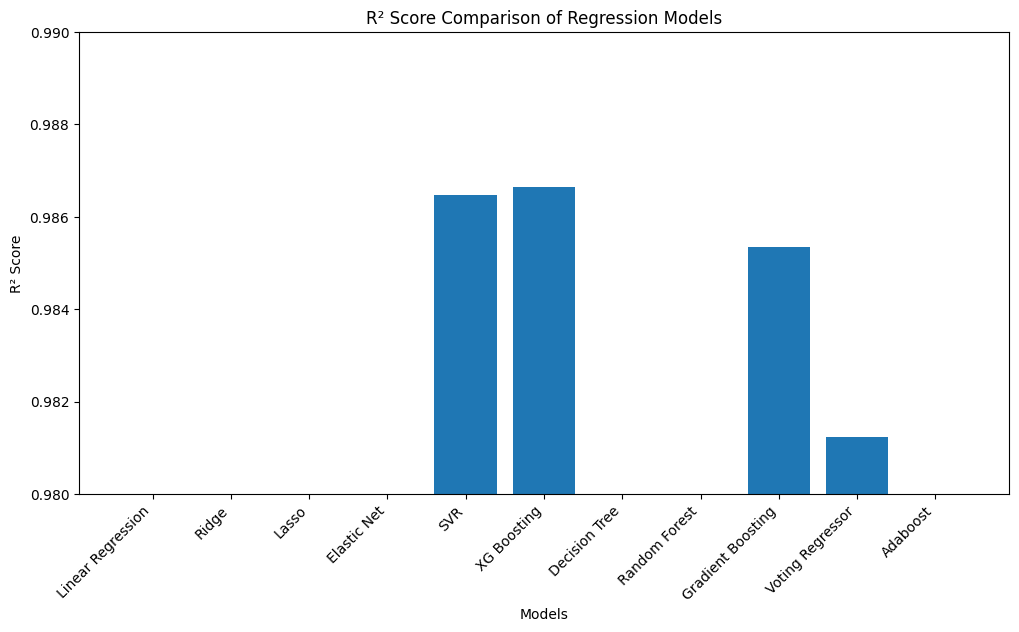

In [43]:
import matplotlib.pyplot as plt

models = [
    "Linear Regression",
    "Ridge",
    "Lasso",
    "Elastic Net",
    "SVR",
    "XG Boosting",
    "Decision Tree",
    "Random Forest",
    "Gradient Boosting",
    "Voting Regressor",
    "Adaboost"
]

r2_scores = [
    lr_r2,
    ridge_r2,
    lasso_r2,
    elastic_r2,
    svr_r2,
    xgb_r2,
    dt_r2,
    rf_r2,
    gb_r2,
    voting_r2,
    ada_r2
]

plt.figure(figsize=(12, 6))
plt.bar(models, r2_scores)

plt.ylabel("R² Score")
plt.xlabel("Models")
plt.title("R² Score Comparison of Regression Models")
plt.xticks(rotation=45, ha="right")
plt.ylim(0.980, 0.9900)

plt.show()

# Final Model Selection - Regression
Among the nine regression algorithms evaluated — Linear Regression, Ridge, Lasso, Elastic Net, Support Vector Regression (SVR), Decision Tree, Random Forest, Gradient Boosting, and the Voting Regressor ensemble — **Support Vector Regression (SVR) emerged as the best-performing model, achieving the lowest test error (MAE: 1.246, RMSE: 2.392) and the highest coefficient of determination (R² = 0.9865) among all candidates**. It outperformed its closest competitor, Gradient Boosting (R²: 0.9853), while exhibiting a minimal train-test gap (Train R²: 0.9929 vs. Test R²: 0.9865), confirming that its performance reflects genuine pattern recognition rather than overfitting — unlike Random Forest, which showed a comparatively larger generalization gap (Train R²: 0.9959 vs. Test R²: 0.9791) despite a respectable test score.

# Train-Test split for Classification

In [44]:
Xc_train, Xc_test, yc_train, yc_test = train_test_split(X, y2, test_size=0.2, random_state=42)
Xc_train, Xc_test = Xc_train.copy(), Xc_test.copy()

# Functional-Log transformer

In [45]:
Xc_train[log_col] = log_transformer.transform(Xc_train[log_col])
Xc_test[log_col] = log_transformer.transform(Xc_test[log_col])

# One Hot Encoding

In [46]:
ohe_c = OneHotEncoder(handle_unknown="ignore", drop="first", sparse_output=False)
Xc_train_cat = pd.DataFrame(ohe_c.fit_transform(Xc_train[ohe_col]),
                             columns=ohe_c.get_feature_names_out(ohe_col), index=Xc_train.index)
Xc_test_cat = pd.DataFrame(ohe_c.transform(Xc_test[ohe_col]),
                            columns=ohe_c.get_feature_names_out(ohe_col), index=Xc_test.index)
Xc_train = pd.concat([Xc_train.drop(columns=ohe_col), Xc_train_cat], axis=1)
Xc_test = pd.concat([Xc_test.drop(columns=ohe_col), Xc_test_cat], axis=1)

# StandardScaler

In [47]:
scaler_c = StandardScaler()
Xc_train[num_col] = scaler_c.fit_transform(Xc_train[num_col]) 
Xc_test[num_col] = scaler_c.transform(Xc_test[num_col])

In [48]:
print(Xc_train[num_col].mean())
print(Xc_train[num_col].std())

Order_Quantity               -3.872458e-16
Distance_km                  -3.872458e-16
Supplier_Lead_Time_days       1.296740e-16
Transportation_Cost           5.142553e-16
Inventory_Level              -2.131628e-17
Demand_Forecast              -6.217249e-18
Supplier_Reliability_Score    6.643575e-16
Historical_Delay_Rate         1.829648e-16
dtype: float64
Order_Quantity                1.000063
Distance_km                   1.000063
Supplier_Lead_Time_days       1.000063
Transportation_Cost           1.000063
Inventory_Level               1.000063
Demand_Forecast               1.000063
Supplier_Reliability_Score    1.000063
Historical_Delay_Rate         1.000063
dtype: float64


# Gaussian Naive Bayes with metrics

In [49]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()

nb.fit(Xc_train, yc_train)

nb_pred = nb.predict(Xc_test)
print("Naive Bayes")
print("Accuracy",accuracy_score(yc_test, nb_pred))
print("Precision",precision_score(yc_test, nb_pred, average="macro"))
print("Recall",recall_score(yc_test, nb_pred, average="macro"))
print("F1 score",f1_score(yc_test, nb_pred, average="macro"))
print("Classification report",classification_report(yc_test, nb_pred))

Naive Bayes
Accuracy 0.442
Precision 0.4947531350098492
Recall 0.5580327981323975
F1 score 0.44388041200526474
Classification report                   precision    recall  f1-score   support

         Delayed       0.40      0.08      0.13       705
           Early       0.58      0.80      0.67       257
         On Time       0.68      0.38      0.48       649
Severely Delayed       0.33      0.98      0.50       389

        accuracy                           0.44      2000
       macro avg       0.49      0.56      0.44      2000
    weighted avg       0.50      0.44      0.38      2000



# Over/Underfitting Check

In [50]:
nbt_pred = nb.predict(Xc_train)
nb_pred = nb.predict(Xc_test)

print("Train acc score:", accuracy_score(yc_train, nbt_pred))
print("Test acc score :",accuracy_score(yc_test, nb_pred))

print("Train f1 score:", f1_score(yc_train, nbt_pred, average="macro"))
print("Test f1 score :", f1_score(yc_test, nb_pred, average="macro"))

Train acc score: 0.438625
Test acc score : 0.442
Train f1 score: 0.43559022731908154
Test f1 score : 0.44388041200526474


# Softmax Classifier with metrics

In [51]:
from sklearn.linear_model import LogisticRegression
softmax = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Train
softmax.fit(Xc_train, yc_train)

# Test prediction
softmax_pred = softmax.predict(Xc_test)

# Evaluation
print("Softmax Regression Classification")
print("------------------")

print("Accuracy :", accuracy_score(yc_test, softmax_pred))

print("Precision:",
      precision_score(yc_test, softmax_pred, average="macro"))

print("Recall   :",
      recall_score(yc_test, softmax_pred, average="macro"))

print("F1 Score :",
      f1_score(yc_test, softmax_pred, average="macro"))

print("\nClassification Report:")
print(classification_report(yc_test, softmax_pred))

Softmax Regression Classification
------------------
Accuracy : 0.8285
Precision: 0.8350700030304414
Recall   : 0.8104094180732866
F1 Score : 0.8211434685802006

Classification Report:
                  precision    recall  f1-score   support

         Delayed       0.82      0.85      0.83       705
           Early       0.85      0.72      0.78       257
         On Time       0.82      0.86      0.84       649
Severely Delayed       0.85      0.81      0.83       389

        accuracy                           0.83      2000
       macro avg       0.84      0.81      0.82      2000
    weighted avg       0.83      0.83      0.83      2000



# Over/Underfitting Check

In [52]:
smt_pred = softmax.predict(Xc_train)
sm_pred = softmax.predict(Xc_test)

print("Train acc score:", accuracy_score(yc_train, smt_pred))
print("Test acc score :",accuracy_score(yc_test, sm_pred))

print("Train f1 score:", f1_score(yc_train, smt_pred, average="macro"))
print("Test f1 score :", f1_score(yc_test, sm_pred, average="macro"))

Train acc score: 0.842875
Test acc score : 0.8285
Train f1 score: 0.8339820112026687
Test f1 score : 0.8211434685802006


# Support Vector Classifier with metrics

In [53]:
from sklearn.svm import SVC
svc = SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale"
)

svc.fit(Xc_train, yc_train)

svc_pred = svc.predict(Xc_test)
# Evaluation
print("SVM classification")
print("------------------")

print("Accuracy :", accuracy_score(yc_test, softmax_pred))

print("Precision:",
      precision_score(yc_test, softmax_pred, average="macro"))

print("Recall   :",
      recall_score(yc_test, softmax_pred, average="macro"))

print("F1 Score :",
      f1_score(yc_test, softmax_pred, average="macro"))

print("\nClassification Report:")
print(classification_report(yc_test, softmax_pred))

SVM classification
------------------
Accuracy : 0.8285
Precision: 0.8350700030304414
Recall   : 0.8104094180732866
F1 Score : 0.8211434685802006

Classification Report:
                  precision    recall  f1-score   support

         Delayed       0.82      0.85      0.83       705
           Early       0.85      0.72      0.78       257
         On Time       0.82      0.86      0.84       649
Severely Delayed       0.85      0.81      0.83       389

        accuracy                           0.83      2000
       macro avg       0.84      0.81      0.82      2000
    weighted avg       0.83      0.83      0.83      2000



# Over/Underfitting Check

In [54]:
svct_pred = svc.predict(Xc_train)
svc_pred = svc.predict(Xc_test)

print("Train acc score:", accuracy_score(yc_train, svct_pred))
print("Test acc score :",accuracy_score(yc_test, svc_pred))

print("Train f1 score:", f1_score(yc_train, svct_pred, average="macro"))
print("Test f1 score :", f1_score(yc_test, svc_pred, average="macro"))

Train acc score: 0.894
Test acc score : 0.8455
Train f1 score: 0.8879256700668219
Test f1 score : 0.8387871287075859


# Decision Tree Classifier with metrics

In [55]:
from sklearn.tree import DecisionTreeClassifier
dtc = DecisionTreeClassifier(
    criterion="gini",
    max_depth=8,
    random_state=42
)

# Train
dtc.fit(Xc_train, yc_train)

# Test prediction
dtc_pred = dtc.predict(Xc_test)
print("Decision Tree classification")
print("------------------")

print("Accuracy :", accuracy_score(yc_test, softmax_pred))

print("Precision:",
      precision_score(yc_test, softmax_pred, average="macro"))

print("Recall   :",
      recall_score(yc_test, softmax_pred, average="macro"))

print("F1 Score :",
      f1_score(yc_test, softmax_pred, average="macro"))

print("\nClassification Report:")
print(classification_report(yc_test, softmax_pred))

Decision Tree classification
------------------
Accuracy : 0.8285
Precision: 0.8350700030304414
Recall   : 0.8104094180732866
F1 Score : 0.8211434685802006

Classification Report:
                  precision    recall  f1-score   support

         Delayed       0.82      0.85      0.83       705
           Early       0.85      0.72      0.78       257
         On Time       0.82      0.86      0.84       649
Severely Delayed       0.85      0.81      0.83       389

        accuracy                           0.83      2000
       macro avg       0.84      0.81      0.82      2000
    weighted avg       0.83      0.83      0.83      2000



# Over/Underfitting Check

In [56]:
dtct_pred = dtc.predict(Xc_train)
dtc_pred = dtc.predict(Xc_test)

print("Train acc score:", accuracy_score(yc_train, dtct_pred))
print("Test acc score :",accuracy_score(yc_test, dtc_pred))

print("Train f1 score:", f1_score(yc_train, dtct_pred, average="macro"))
print("Test f1 score :", f1_score(yc_test, dtc_pred, average="macro"))

Train acc score: 0.86775
Test acc score : 0.804
Train f1 score: 0.8609741208834896
Test f1 score : 0.7956429749902023


# Voting Classifier with metrics

In [57]:
from sklearn.ensemble import VotingClassifier
dtv = DecisionTreeClassifier(
    criterion="gini",
    max_depth=8,
    random_state=42
)

softmaxv = LogisticRegression(
    max_iter=1000,
    random_state=42
)

svcv = SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale",
    probability=True,
    random_state=42
)

# --------------------------------
# 2. Create Voting Classifier
# --------------------------------

voting_clf = VotingClassifier(
    estimators=[
        ("dt", dtv),
        ("softmax", softmaxv),
        ("svc", svcv)
    ],
    voting="soft"
)

# --------------------------------
# 3. Train
# --------------------------------

voting_clf.fit(Xc_train, yc_train)

# --------------------------------
# 4. Test prediction
# --------------------------------

voting_pred = voting_clf.predict(Xc_test)

print("Voting classification")
print("------------------")

print("Accuracy :", accuracy_score(yc_test, softmax_pred))

print("Precision:",
      precision_score(yc_test, softmax_pred, average="macro"))

print("Recall   :",
      recall_score(yc_test, softmax_pred, average="macro"))

print("F1 Score :",
      f1_score(yc_test, softmax_pred, average="macro"))

print("\nClassification Report:")
print(classification_report(yc_test, softmax_pred))

Voting classification
------------------
Accuracy : 0.8285
Precision: 0.8350700030304414
Recall   : 0.8104094180732866
F1 Score : 0.8211434685802006

Classification Report:
                  precision    recall  f1-score   support

         Delayed       0.82      0.85      0.83       705
           Early       0.85      0.72      0.78       257
         On Time       0.82      0.86      0.84       649
Severely Delayed       0.85      0.81      0.83       389

        accuracy                           0.83      2000
       macro avg       0.84      0.81      0.82      2000
    weighted avg       0.83      0.83      0.83      2000



# Over/Underfitting Check

In [58]:
voting_clft_pred = voting_clf.predict(Xc_train) 
voting_clf_pred = voting_clf.predict(Xc_test)

print("Train acc score:", accuracy_score(yc_train, voting_clft_pred))
print("Test acc score :",accuracy_score(yc_test, voting_clf_pred))

print("Train f1 score:", f1_score(yc_train, voting_clft_pred, average="macro"))
print("Test f1 score :", f1_score(yc_test, voting_clf_pred, average="macro"))

Train acc score: 0.894375
Test acc score : 0.8425
Train f1 score: 0.8877138329126137
Test f1 score : 0.834902048167982


# KNN classifier with metrics

In [59]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(
    n_neighbors=5,
    weights="distance"
)

# --------------------------------
# 2. Train
# --------------------------------

knn.fit(Xc_train, yc_train)

# --------------------------------
# 3. Test prediction
# --------------------------------

knn_pred = knn.predict(Xc_test)

print("KNN classification")
print("------------------")

print("Accuracy :", accuracy_score(yc_test, softmax_pred))

print("Precision:",
      precision_score(yc_test, softmax_pred, average="macro"))

print("Recall   :",
      recall_score(yc_test, softmax_pred, average="macro"))

print("F1 Score :",
      f1_score(yc_test, softmax_pred, average="macro"))

print("\nClassification Report:")
print(classification_report(yc_test, softmax_pred))

KNN classification
------------------
Accuracy : 0.8285
Precision: 0.8350700030304414
Recall   : 0.8104094180732866
F1 Score : 0.8211434685802006

Classification Report:
                  precision    recall  f1-score   support

         Delayed       0.82      0.85      0.83       705
           Early       0.85      0.72      0.78       257
         On Time       0.82      0.86      0.84       649
Severely Delayed       0.85      0.81      0.83       389

        accuracy                           0.83      2000
       macro avg       0.84      0.81      0.82      2000
    weighted avg       0.83      0.83      0.83      2000



# Over/Underfitting Check

In [60]:
knnt_pred = knn.predict(Xc_train) 
knn_pred = knn.predict(Xc_test)

print("Train acc score:", accuracy_score(yc_train, knnt_pred))
print("Test acc score :",accuracy_score(yc_test, knn_pred))

print("Train f1 score:", f1_score(yc_train, knnt_pred, average="macro"))
print("Test f1 score :", f1_score(yc_test, knn_pred, average="macro"))

Train acc score: 1.0
Test acc score : 0.7455
Train f1 score: 1.0
Test f1 score : 0.7413214578553646


# Random Forest Classifier with metrics

In [61]:
from sklearn.ensemble import RandomForestClassifier
rfc = RandomForestClassifier(
    n_estimators=250,
    max_depth=12,
    random_state=42,
    n_jobs=-1
)

rfc.fit(Xc_train, yc_train)

rf_pred = rfc.predict(Xc_test)

print("Random Forest Classifier")
print("------------------------")
print("Accuracy :", accuracy_score(yc_test, rf_pred))
print("Precision:", precision_score(yc_test, rf_pred, average="macro"))
print("Recall   :", recall_score(yc_test, rf_pred, average="macro"))
print("F1 Score :", f1_score(yc_test, rf_pred, average="macro"))

print("\nClassification Report:")
print(classification_report(yc_test, rf_pred))

Random Forest Classifier
------------------------
Accuracy : 0.837
Precision: 0.8427334409626424
Recall   : 0.8137627915309791
F1 Score : 0.8258781962396792

Classification Report:
                  precision    recall  f1-score   support

         Delayed       0.85      0.86      0.85       705
           Early       0.83      0.68      0.75       257
         On Time       0.80      0.87      0.83       649
Severely Delayed       0.90      0.85      0.87       389

        accuracy                           0.84      2000
       macro avg       0.84      0.81      0.83      2000
    weighted avg       0.84      0.84      0.84      2000



# Over/Underfitting Check

In [62]:
rft_pred = rfc.predict(Xc_train) 
rf_pred = rfc.predict(Xc_test)

print("Train acc score:", accuracy_score(yc_train, rft_pred))
print("Test acc score :",accuracy_score(yc_test, rf_pred))

print("Train f1 score:", f1_score(yc_train, rft_pred, average="macro"))
print("Test f1 score :", f1_score(yc_test, rf_pred, average="macro"))

Train acc score: 0.959875
Test acc score : 0.837
Train f1 score: 0.956139364094817
Test f1 score : 0.8258781962396792


# AdaBoost Classifier with metrics

In [63]:
from sklearn.ensemble import AdaBoostClassifier
adac = AdaBoostClassifier(
    n_estimators=150,
    learning_rate=0.1,
    random_state=42
)

adac.fit(Xc_train, yc_train)
adac_pred = adac.predict(Xc_test)

print("AdaBoost Classifier")
print("------------------------")
print("Accuracy :", accuracy_score(yc_test, rf_pred))
print("Precision:", precision_score(yc_test, rf_pred, average="macro"))
print("Recall   :", recall_score(yc_test, rf_pred, average="macro"))
print("F1 Score :", f1_score(yc_test, rf_pred, average="macro"))

print("\nClassification Report:")
print(classification_report(yc_test, rf_pred))

AdaBoost Classifier
------------------------
Accuracy : 0.837
Precision: 0.8427334409626424
Recall   : 0.8137627915309791
F1 Score : 0.8258781962396792

Classification Report:
                  precision    recall  f1-score   support

         Delayed       0.85      0.86      0.85       705
           Early       0.83      0.68      0.75       257
         On Time       0.80      0.87      0.83       649
Severely Delayed       0.90      0.85      0.87       389

        accuracy                           0.84      2000
       macro avg       0.84      0.81      0.83      2000
    weighted avg       0.84      0.84      0.84      2000



# Over/Underfitting Check

In [64]:
adact_pred = adac.predict(Xc_train) 
adac_pred = adac.predict(Xc_test)

print("Train acc score:", accuracy_score(yc_train, adact_pred))
print("Test acc score :",accuracy_score(yc_test, adac_pred))

print("Train f1 score:", f1_score(yc_train, adact_pred, average="macro"))
print("Test f1 score :", f1_score(yc_test, adac_pred, average="macro"))

Train acc score: 0.67
Test acc score : 0.6505
Train f1 score: 0.5424362896144291
Test f1 score : 0.5294580626416595


# Gradient Boosting Classifier with metrics

In [65]:
from sklearn.ensemble import GradientBoostingClassifier
gb_clf = GradientBoostingClassifier(
    n_estimators=250,
    learning_rate=0.08,
    max_depth=3,
    random_state=42
)

gb_clf.fit(Xc_train, yc_train)

gb_clf_pred = gb_clf.predict(Xc_test)

print("Gradient Boosting Classifier")
print("----------------------------")
print("Accuracy :", accuracy_score(yc_test, gb_clf_pred))
print("Precision:", precision_score(yc_test, gb_clf_pred, average="macro"))
print("Recall   :", recall_score(yc_test, gb_clf_pred, average="macro"))
print("F1 Score :", f1_score(yc_test, gb_clf_pred, average="macro"))

print("\nClassification Report:")
print(classification_report(yc_test, gb_clf_pred))

Gradient Boosting Classifier
----------------------------
Accuracy : 0.854
Precision: 0.8542454278467495
Recall   : 0.8419886063289039
F1 Score : 0.8475488807070939

Classification Report:
                  precision    recall  f1-score   support

         Delayed       0.87      0.86      0.86       705
           Early       0.83      0.76      0.79       257
         On Time       0.83      0.87      0.85       649
Severely Delayed       0.89      0.88      0.88       389

        accuracy                           0.85      2000
       macro avg       0.85      0.84      0.85      2000
    weighted avg       0.85      0.85      0.85      2000



# Over/Underfitting Check

In [66]:
gb_clft_pred = gb_clf.predict(Xc_train) 
gb_clf_pred = gb_clf.predict(Xc_test)

print("Train acc score:", accuracy_score(yc_train, gb_clft_pred))
print("Test acc score :",accuracy_score(yc_test, gb_clf_pred))

print("Train f1 score:", f1_score(yc_train, gb_clft_pred, average="macro"))
print("Test f1 score :", f1_score(yc_test, gb_clf_pred, average="macro"))

Train acc score: 0.935125
Test acc score : 0.854
Train f1 score: 0.9317402199243761
Test f1 score : 0.8475488807070939


# XG Boost Classifier with metrics

In [67]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

# Encode target
le_xgb = LabelEncoder()

yc_train_encoded = le_xgb.fit_transform(yc_train)
yc_test_encoded = le_xgb.transform(yc_test)

# XGBoost Classifier
xgb_clf = XGBClassifier(
    n_estimators=250,
    max_depth=4,
    learning_rate=0.05,
    random_state=42,
    objective="multi:softprob",
    num_class=4,
    eval_metric="mlogloss"
)

# Use encoded target here
xgb_clf.fit(Xc_train, yc_train_encoded)

# Prediction
xgb_clf_pred = xgb_clf.predict(Xc_test)

print("XGBoost Classifier")
print("------------------")
print("Accuracy :", accuracy_score(yc_test_encoded, xgb_clf_pred))
print("Precision:", precision_score(yc_test_encoded, xgb_clf_pred, average="macro"))
print("Recall   :", recall_score(yc_test_encoded, xgb_clf_pred, average="macro"))
print("F1 Score :", f1_score(yc_test_encoded, xgb_clf_pred, average="macro"))

print("\nClassification Report:")
print(classification_report(
    yc_test_encoded,
    xgb_clf_pred,
    target_names=le_xgb.classes_
))

XGBoost Classifier
------------------
Accuracy : 0.853
Precision: 0.8538519637513151
Recall   : 0.844500285575089
F1 Score : 0.8484434699329604

Classification Report:
                  precision    recall  f1-score   support

         Delayed       0.88      0.84      0.86       705
           Early       0.83      0.77      0.80       257
         On Time       0.81      0.88      0.85       649
Severely Delayed       0.89      0.89      0.89       389

        accuracy                           0.85      2000
       macro avg       0.85      0.84      0.85      2000
    weighted avg       0.85      0.85      0.85      2000



# Over/Underfitting Check

In [68]:
# Predictions on train and test data
xgb_clf_train_pred = xgb_clf.predict(Xc_train)
xgb_clf_test_pred = xgb_clf.predict(Xc_test)

# Accuracy
train_acc = accuracy_score(yc_train_encoded, xgb_clf_train_pred)
test_acc = accuracy_score(yc_test_encoded, xgb_clf_test_pred)

# Macro F1
train_f1 = f1_score(
    yc_train_encoded,
    xgb_clf_train_pred,
    average="macro"
)

test_f1 = f1_score(
    yc_test_encoded,
    xgb_clf_test_pred,
    average="macro"
)
print("XGBoost Classifier - Over/Underfitting Check")
print("-----------------------------------------------")

print("Train Accuracy:", round(train_acc, 4))
print("Test Accuracy :", round(test_acc, 4))

print("Train F1      :", round(train_f1, 4))
print("Test F1       :", round(test_f1, 4)) 

XGBoost Classifier - Over/Underfitting Check
-----------------------------------------------
Train Accuracy: 0.9209
Test Accuracy : 0.853
Train F1      : 0.9166
Test F1       : 0.8484


# Classification Model Metrics Comparison with visualization

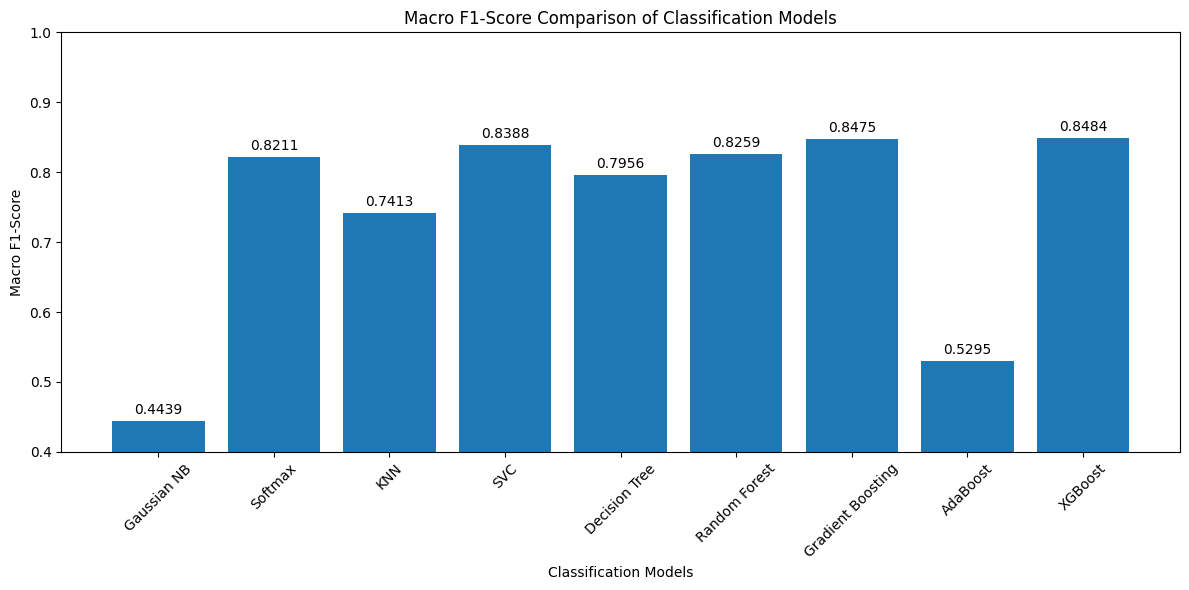

In [69]:
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score

# Calculate Macro F1-score for each model
f1_scores = {
    "Gaussian NB": f1_score(yc_test, nb_pred, average="macro"),
    "Softmax": f1_score(yc_test, softmax_pred, average="macro"),
    "KNN": f1_score(yc_test, knn_pred, average="macro"),
    "SVC": f1_score(yc_test, svc_pred, average="macro"),
    "Decision Tree": f1_score(yc_test, dtc_pred, average="macro"),
    "Random Forest": f1_score(yc_test, rf_pred, average="macro"),
    "Gradient Boosting": f1_score(yc_test, gb_clf_pred, average="macro"),
    "AdaBoost": f1_score(yc_test, adac_pred, average="macro"),
    "XGBoost": f1_score(yc_test_encoded, xgb_clf_pred, average="macro")
}

# Plot
plt.figure(figsize=(12, 6))

bars = plt.bar(f1_scores.keys(), f1_scores.values())

plt.xlabel("Classification Models")
plt.ylabel("Macro F1-Score")
plt.title("Macro F1-Score Comparison of Classification Models")
plt.xticks(rotation=45)
plt.ylim(0.4, 1)

# Add values on top of bars
for bar, score in zip(bars, f1_scores.values()):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f"{score:.4f}",
        ha="center"
    )

plt.tight_layout()
plt.show()

# Model Selection - Classification
Among the nine classification algorithms evaluated — Naive Bayes, Logistic Regression (Softmax), Support Vector Machine, Decision Tree, K-Nearest Neighbors, Random Forest, AdaBoost, Gradient Boosting, and XGBoost — **XGBoost emerged as the best-performing model, achieving a test accuracy of 85.3% and a weighted F1-score of 0.8484, the highest among all candidates**. It narrowly outperformed Gradient Boosting (F1: 0.8475), its closest competitor, while maintaining a comparatively controlled train-test gap (Train F1: 0.9166 vs. Test F1: 0.8484), indicating stronger generalization than other high-capacity models such as Random Forest and KNN, both of which showed pronounced overfitting (train F1 approaching or reaching 1.0).

# K-Means Clustering with metrics

In [70]:
cluster_cols = [
    "Order_Quantity",
    "Distance_km",
    "Supplier_Lead_Time_days",
    "Transportation_Cost",
    "Inventory_Level",
    "Demand_Forecast",
    "Supplier_Reliability_Score",
    "Historical_Delay_Rate"
]

X_cluster = df[cluster_cols].copy()

In [71]:
scaler_cluster = StandardScaler()
X_cluster_scaled = scaler_cluster.fit_transform(X_cluster)

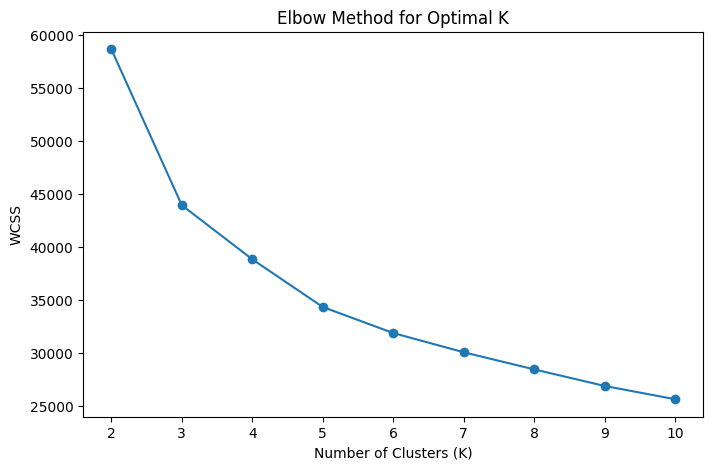

In [72]:
from sklearn.cluster import KMeans
wcss = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(X_cluster_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), wcss, marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method for Optimal K")
plt.show()

Elbow method is used to find the best value of K.

In [73]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)
kmeans_labels = kmeans.fit_predict(X_cluster_scaled)
df["Shipment_Profile"] = kmeans_labels

# Creating Shipment profile
A Shipment Profile is the group or category assigned to a shipment based on its similarity to other shipments. The 5 clusters are not predefined categories. K-Means discovers them from the data based on similarities in the 8 numerical features. 0,1,2,3,4 are the 5 clusters the algo generated here based on the k value(that is 5).

In [74]:
cluster_profile = df.groupby("Shipment_Profile")[cluster_cols].mean()

print(cluster_profile)

                  Order_Quantity  Distance_km  Supplier_Lead_Time_days  \
Shipment_Profile                                                         
0                     334.820355  7924.189437                16.835775   
1                     300.954435  9022.134852                19.671652   
2                    2352.925816  7908.157270                11.044510   
3                    1218.319106  7502.794173                13.396341   
4                     345.263797  4779.813355                 7.859088   

                  Transportation_Cost  Inventory_Level  Demand_Forecast  \
Shipment_Profile                                                          
0                         8601.983701       290.126831       352.898612   
1                         6616.005043       264.254609       321.119304   
2                       126979.514362      2268.688427      2613.436202   
3                        37643.368103      1149.065041      1324.435637   
4                         6484.

# Visualization of numerical columns' shipment profile

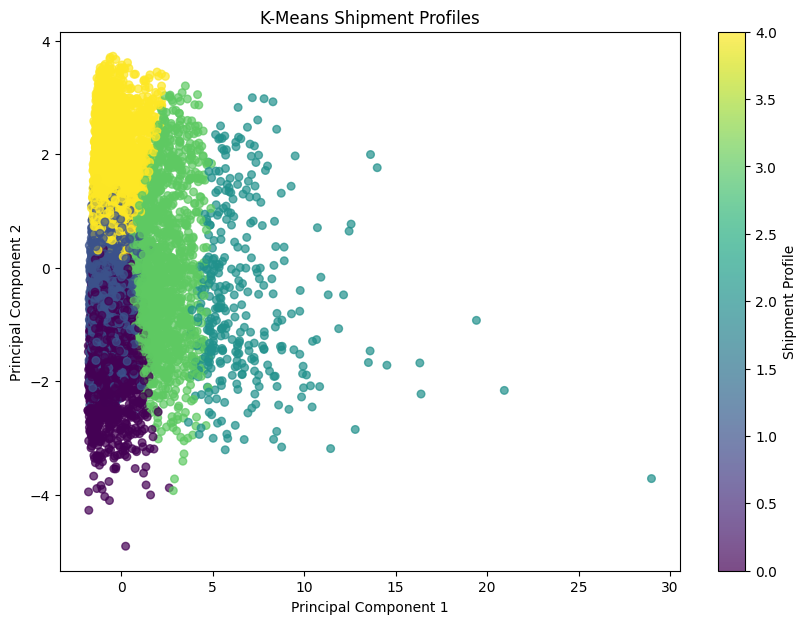

In [75]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Reduce 8 features to 2 dimensions
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_cluster_scaled)

# Plot clusters
plt.figure(figsize=(10, 7))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=kmeans_labels,
    cmap="viridis",
    s=30,
    alpha=0.7
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Shipment Profiles")
plt.colorbar(label="Shipment Profile")

plt.show()

# Checking Silhouette Score
It ranges from -1 to 1. 
Silhouette Score:	    Meaning:
    +1:	                Excellent clustering — the point is very close to its own cluster and far from other clusters. 
    0:	                Overlapping/boundary point — the point is almost equally close to its own cluster and another cluster. 
   −1:	                Poor clustering — the point is likely closer to another cluster than to its assigned cluster.

In [76]:
from sklearn.metrics import silhouette_score

sil_score = silhouette_score(
    X_cluster_scaled,
    kmeans_labels
)

print("Silhouette Score:", sil_score)

Silhouette Score: 0.2286488119965664


# DBSCAN (Density-Based Spatial Clustering of Applications with Noise)
It is an unsupervised machine learning clustering algorithm that groups data points based on their density and identifies points in low-density regions as noise or potential anomalies.

In [77]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(
    eps=0.95,
    min_samples=5
)

dbscan_labels = dbscan.fit_predict(X_cluster_scaled)
df["DBSCAN_Cluster"] = dbscan_labels
print(df["DBSCAN_Cluster"].value_counts().sort_index())

DBSCAN_Cluster
-1     977
 0    8974
 1       6
 2       8
 3       4
 4       6
 5      11
 6       4
 7       5
 8       5
Name: count, dtype: int64


In [78]:
anomalies = df[df["DBSCAN_Cluster"] == -1]

print("Number of potential anomalies:", len(anomalies)) 
print("\n")
print(anomalies[cluster_cols].head())

Number of potential anomalies: 977


    Order_Quantity  Distance_km  Supplier_Lead_Time_days  Transportation_Cost  \
1           1786.0       3226.7                      7.0             51125.28   
14          1416.0       6329.9                     10.0             70325.23   
34          2172.0       9463.6                     22.0             22402.36   
46          1541.0       7941.1                      7.0             38513.81   
56          1586.0      11451.6                     16.0            151706.47   

    Inventory_Level  Demand_Forecast  Supplier_Reliability_Score  \
1            2594.0           2511.0                        93.2   
14           1674.0           1365.0                        77.3   
34           1676.0           2113.0                        80.0   
46           1622.0           1575.0                        96.7   
56           1893.0           1500.0                        79.5   

    Historical_Delay_Rate  
1                   0.097  
14         

# Prediction for a newly entered data with all the feature descriptions

In [80]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import pairwise_distances


# ============================================================
# 1. ENTER NEW SHIPMENT DATA
# ============================================================

new_data = pd.DataFrame({
    "Product_Category": ["Electronics"],
    "Supplier_Region": ["North"],
    "Shipping_Mode": ["Air"],
    "Warehouse_Type": ["Regional"],

    "Order_Quantity": [5000],
    "Distance_km": [4500],
    "Supplier_Lead_Time_days": [8],
    "Transportation_Cost": [12000],
    "Inventory_Level": [600],
    "Demand_Forecast": [650],
    "Supplier_Reliability_Score": [88],
    "Historical_Delay_Rate": [0.06]
})


# ============================================================
# 2. DEFINE COLUMNS
# ============================================================

cat_cols = [
    "Product_Category",
    "Supplier_Region",
    "Shipping_Mode",
    "Warehouse_Type"
]

num_cols = [
    "Order_Quantity",
    "Distance_km",
    "Supplier_Lead_Time_days",
    "Transportation_Cost",
    "Inventory_Level",
    "Demand_Forecast",
    "Supplier_Reliability_Score",
    "Historical_Delay_Rate"
]

log_cols = [
    "Order_Quantity",
    "Distance_km",
    "Transportation_Cost",
    "Inventory_Level",
    "Demand_Forecast"
]

cluster_cols = num_cols.copy()


# ============================================================
# 3. CREATING SAME PREPROCESSING FOR NEW DATA
# ============================================================

# ---------- LOG TRANSFORMATION ----------

new_processed = new_data.copy()

new_processed[log_cols] = np.log1p(
    new_processed[log_cols]
)


# ---------- ONE-HOT ENCODING ----------

ohe_new = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

# Fit encoder using original categorical values
ohe_new.fit(df[cat_cols])

encoded_new = ohe_new.transform(
    new_processed[cat_cols]
)

encoded_new_df = pd.DataFrame(
    encoded_new,
    columns=ohe_new.get_feature_names_out(cat_cols),
    index=new_processed.index
)

new_processed = new_processed.drop(
    columns=cat_cols
)

new_processed = pd.concat(
    [new_processed, encoded_new_df],
    axis=1
)


# ---------- STANDARD SCALING ----------

scaler_new = StandardScaler()

training_numeric = df[num_cols].copy()

training_numeric[log_cols] = np.log1p(
    training_numeric[log_cols]
)

scaler_new.fit(
    training_numeric[num_cols]
)

new_processed[num_cols] = scaler_new.transform(
    new_processed[num_cols]
)


# ============================================================
# 4. MAKE COLUMN ORDER SAME AS TRAINING
# ============================================================

new_processed = new_processed[
    Xr_train.columns
]


# ============================================================
# 5. PREDICT DELIVERY TIME
# ============================================================

predicted_delivery_time = svr.predict(
    new_processed
)[0]

predicted_delivery_time = max(
    predicted_delivery_time,
    0
)


# ============================================================
# 6. PREDICT DELIVERY STATUS
# ============================================================

predicted_status_encoded = xgb_clf.predict(
    new_processed
)

predicted_status = le_xgb.inverse_transform(
    predicted_status_encoded.astype(int)
)[0]


# ============================================================
# 7. K-MEANS → SHIPMENT PROFILE
# ============================================================

new_cluster = new_data[cluster_cols].copy()

new_cluster[log_cols] = np.log1p(
    new_cluster[log_cols]
)

cluster_scaler_new = StandardScaler()

cluster_training = df[cluster_cols].copy()

cluster_training[log_cols] = np.log1p(
    cluster_training[log_cols]
)

cluster_scaler_new.fit(
    cluster_training
)

new_cluster_scaled = cluster_scaler_new.transform(
    new_cluster
)

predicted_cluster = kmeans.predict(
    new_cluster_scaled
)[0]


# ============================================================
# 8. DBSCAN → ANOMALY STATUS
# ============================================================

# DBSCAN does not have a normal predict() method for new data.
# Therefore, compare the new shipment with the DBSCAN core samples.

core_samples = dbscan.components_

distance_to_core = pairwise_distances(
    new_cluster_scaled,
    core_samples
)

minimum_distance = distance_to_core.min()

if minimum_distance <= dbscan.eps:
    dbscan_status = "Normal"
else:
    dbscan_status = "Potential Anomaly"


# ============================================================
# 9. FINAL SUPPLY CHAIN INTELLIGENCE OUTPUT
# ============================================================

print("\n" + "=" * 60)
print("              SUPPLY CHAIN INTELLIGENCE")
print("=" * 60) 

print(
    f"Predicted Delivery Time  : "
    f"{predicted_delivery_time:.2f} days"
)

print(
    f"Predicted Delivery Status: "
    f"{predicted_status}"
)

print(
    f"Shipment Profile         : "
    f"Cluster {predicted_cluster}"
)

print(
    f"DBSCAN Anomaly Status    : "
    f"{dbscan_status}"
) 

print("=" * 60)


              SUPPLY CHAIN INTELLIGENCE
Predicted Delivery Time  : 14.98 days
Predicted Delivery Status: Early
Shipment Profile         : Cluster 3
DBSCAN Anomaly Status    : Potential Anomaly


# Conclusion
This project built an end-to-end Supply Chain Intelligence pipeline covering data cleaning, EDA, feature engineering, supervised learning, and unsupervised learning on a 10,000-record shipment dataset.

For predicting Delivery Time, SVR performed best (R² = 0.9865, MAE = 1.246), narrowly ahead of Gradient Boosting, and clearly ahead of linear models (R² ≈ 0.94) — confirming delivery time depends on non-linear interactions between distance, supplier reliability, and delay history rather than simple additive effects. For predicting Delivery Status, XGBoost performed best (F1 = 0.8484, Accuracy = 85.3%), again ahead of linear and probabilistic baselines like Logistic Regression and Naive Bayes.

KMeans segmented shipments into distinct operational profiles, and DBSCAN flagged a small subset of shipments as anomalies based on unusual feature combinations — both providing insight independent of the labeled targets, and reinforcing the same high-risk pattern (long distance, low reliability, high delay rate) found by the supervised models.

Overall, ensemble and kernel-based methods consistently outperformed linear models across both tasks, confirming that supply chain outcomes here are driven by compounding, non-linear relationships. The final pipeline — SVR + XGBoost + KMeans/DBSCAN — delivers a complete system for forecasting delays, classifying risk, and flagging anomalies from shipment data.